In [244]:
import pandas as pd
import numpy as np

In [245]:
cradit_data=pd.read_csv('Datasets/tmdb_5000_credits.csv')
movies_data=pd.read_csv('Datasets/tmdb_5000_movies.csv')

In [246]:
movies_data.sample(10)

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
1534,31000000,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 27, ""nam...",NaN,6488,"[{""id"": 1415, ""name"": ""small town""}, {""id"": 97...",en,Arachnophobia,A large spider from the jungles of South Ameri...,15.895661,"[{""name"": ""Amblin Entertainment"", ""id"": 56}, {...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",1990-08-09,53208180,103.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,"Eight legs, two fangs, and an attitude.",Arachnophobia,6.2,433
4420,0,"[{""id"": 53, ""name"": ""Thriller""}, {""id"": 27, ""n...",NaN,84178,"[{""id"": 9713, ""name"": ""friends""}, {""id"": 15663...",en,Black Rock,Three childhood friends set aside their person...,7.207051,"[{""name"": ""Submarine Entertainment Distributor...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-01-21,0,83.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Not every island is a paradise.,Black Rock,4.9,78
2700,14000000,"[{""id"": 18, ""name"": ""Drama""}]",NaN,2013,"[{""id"": 1731, ""name"": ""writing""}, {""id"": 1808,...",fr,Le scaphandre et le papillon,"Elle France editor Jean-Dominique Bauby, who, ...",13.654940,"[{""name"": ""France 3 Cin\u00e9ma"", ""id"": 591}, ...","[{""iso_3166_1"": ""FR"", ""name"": ""France""}, {""iso...",2007-05-22,19777647,112.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}]",Released,Let your imagination set you free,The Diving Bell and the Butterfly,7.4,283
4548,500000,"[{""id"": 18, ""name"": ""Drama""}]",NaN,81220,"[{""id"": 10183, ""name"": ""independent film""}]",en,Everything Put Together,Everything Put Together is a 2000 film directe...,0.046903,"[{""name"": ""Furst Films"", ""id"": 3135}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2001-11-02,0,87.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,Everything Put Together,5.0,2
2096,13000000,"[{""id"": 27, ""name"": ""Horror""}, {""id"": 53, ""nam...",http://theconjuring.warnerbros.com,138843,"[{""id"": 1156, ""name"": ""sister sister relations...",en,The Conjuring,Paranormal investigators Ed and Lorraine Warre...,49.975409,"[{""name"": ""New Line Cinema"", ""id"": 12}, {""name...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2013-07-18,318000141,112.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Based on the true case files of the Warrens,The Conjuring,7.4,3092
2030,22000000,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 53, ""name...",http://weinsteinco.com/films/derailed/,8999,"[{""id"": 378, ""name"": ""prison""}, {""id"": 520, ""n...",en,Derailed,When two married business executives having an...,17.709100,"[{""name"": ""Miramax Films"", ""id"": 14}, {""name"":...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2005-11-11,57479076,108.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,He never saw it coming.,Derailed,6.1,319
2405,17000000,"[{""id"": 27, ""name"": ""Horror""}, {""id"": 53, ""nam...",NaN,3597,"[{""id"": 1328, ""name"": ""secret""}, {""id"": 1936, ...",en,I Know What You Did Last Summer,As they celebrate their high school graduation...,27.654472,"[{""name"": ""Columbia Pictures Corporation"", ""id...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",1997-10-17,125586134,100.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"If you're going to bury the truth, make sure i...",I Know What You Did Last Summer,5.6,687
2166,20000000,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 18, ""na...",NaN,577,"[{""id"": 596, ""name"": ""adultery""}, {""id"": 1442,...",en,To Die For,Susan wants to work in television and will the...,12.309715,"[{""name"": ""The Rank Organisation"", ""id"": 364},...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",1995-05-20

In [247]:
def text_extractor(text):
   s=""
   m=text.split('}')
   for j in m:
      try:
        x= j.split(':')[2].strip().strip('"')
        s+=x+',' 
      except IndexError:
        break
   return s      

In [248]:
genres=movies_data['genres'].apply(text_extractor)

In [249]:
cradit_data=cradit_data.drop(columns='title')

In [250]:
data=movies_data.merge(cradit_data,left_on='id',right_on='movie_id').drop(columns=['movie_id','homepage','original_language','production_companies'])

In [251]:
data=data[['genres','id','keywords','title','overview','cast','crew']]

In [252]:
keywords=data['keywords'].apply(text_extractor)

In [253]:
data.head()

,genres,id,keywords,title,overview,cast,crew
0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",Spectre,A cryptic message from Bond’s past sends him o...,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",John Carter,"John Carter is a war-weary, former military ca...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


In [254]:
cast=data['cast'].apply(text_extractor)

In [255]:
cast[0]

'Jake Sully", "credit_id,Neytiri", "credit_id,Dr. Grace Augustine", "credit_id,Col. Quaritch", "credit_id,Trudy Chacon", "credit_id,Selfridge", "credit_id,Norm Spellman", "credit_id,Moat", "credit_id,Eytukan", "credit_id,Tsu\'Tey", "credit_id,Dr. Max Patel", "credit_id,Lyle Wainfleet", "credit_id,Private Fike", "credit_id,Cryo Vault Med Tech", "credit_id,Venture Star Crew Chief", "credit_id,Lock Up Trooper", "credit_id,Shuttle Pilot", "credit_id,Shuttle Co-Pilot", "credit_id,Shuttle Crew Chief", "credit_id,Tractor Operator / Troupe", "credit_id,Dragon Gunship Pilot", "credit_id,Dragon Gunship Gunner", "credit_id,Dragon Gunship Navigator", "credit_id,Suit #1", "credit_id,Suit #2", "credit_id,Ambient Room Tech", "credit_id,Ambient Room Tech / Troupe", "credit_id,Horse Clan Leader", "credit_id,Link Room Tech", "credit_id,Basketball Avatar / Troupe", "credit_id,Basketball Avatar", "credit_id,Na\'vi Child", "credit_id,Troupe", "credit_id,Troupe", "credit_id,Troupe", "credit_id,Troupe", "cre

In [256]:
data.isnull().sum() # 3 value missing in overview

genres      0
id          0
keywords    0
title       0
overview    3
cast        0
crew        0
dtype: int64

In [257]:
data.duplicated().sum()

np.int64(0)

In [258]:
data[data['genres']=='[]'].shape # 28 missing genres 

(28, 7)

In [259]:
data['id'].isnull().sum() # no missing value 

np.int64(0)

In [260]:
data.sample()

,genres,id,keywords,title,overview,cast,crew
1081,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10749, ""n...",4148,"[{""id"": 596, ""name"": ""adultery""}, {""id"": 931, ...",Revolutionary Road,A young couple living in a Connecticut suburb ...,"[{""cast_id"": 2, ""character"": ""Frank Wheeler"", ...","[{""credit_id"": ""56329bb69251413b46005dc8"", ""de..."


In [261]:
data[data['keywords']=='[]'].shape # 412 missing value 

(412, 7)

In [262]:
412/data.shape[0]  # missing in % 

0.08577972100770352

In [263]:
data[data['cast']=='[]'].shape # 43 value missing 

(43, 7)

In [264]:
data[(data['cast']=='[]') |  (data['keywords']=='[]') | (data['genres']=='[]')]

,genres,id,keywords,title,overview,cast,crew
71,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 28, ""...",1735,[],The Mummy: Tomb of the Dragon Emperor,"Archaeologist Rick O'Connell travels to China,...","[{""cast_id"": 1, ""character"": ""Richard O'Connel...","[{""credit_id"": ""52fe4312c3a36847f80384c5"", ""de..."
83,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",79698,[],The Lovers,The Lovers is an epic romance time travel adve...,"[{""cast_id"": 11, ""character"": ""James Stewart /...","[{""credit_id"": ""52fe49e0c3a368484e145067"", ""de..."
323,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 18, ""nam...",37786,[],Sex and the City 2,"Carrie, Charlotte, and Miranda are all married...","[{""cast_id"": 2, ""character"": ""Carrie Bradshaw""...","[{""credit_id"": ""555893a492514129b70020b9"", ""de..."
381,"[{""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""na...",49852,[],The Nutcracker: The Untold Story,"Set in 1920's Vienna, this a tale of a little ...","[{""cast_id"": 6, ""character"": ""Mary"", ""credit_i...","[{""credit_id"": ""5387691d0e0a26144d004120"", ""de..."
436,"[{""id"": 35, ""name"": ""Comedy""}]",109418,[],Grown Ups 2,The all-star comedy cast from Grown Ups return...,"[{""cast_id"": 5, ""character"": ""Lenny Feder"", ""c...","[{""credit_id"": ""52fe4ab4c3a36847f81dd247"", ""de..."
...,...,...,...,...,...,...,...
4790,"[{""id"": 18, ""name"": ""Drama""}, {""id"": 10769, ""n...",13898,[],The Circle,Various women struggle to function in the oppr...,"[{""cast_id"": 3, ""character"": ""Nargess"", ""credi...","[{""credit_id"": ""52fe45b09251416c7505f189"", ""de..."
4794,"[{""id"": 53, ""name"": ""Thriller""}, {""id"": 27, ""n...",286939,[],Sanctuary: Quite a Conundrum,"It should have been just a normal day of sex, ...","[{""cast_id"": 3, ""character"": ""Mimi"", ""credit_i...","[{""credit_id"": ""545f8107c3a3686cbb0041fd"", ""de..."
4797,"[{""id"": 10769, ""name"": ""Foreign""}, {""id"": 53, ...",67238,[],Cavite,"Adam, a security guard, travels from Californi...",[],"[{""credit_id"": ""52fe475dc3a368484e0c319f"", ""de..."
4799,"[{""id"": 35, ""name"": ""Comedy""}, {""id"": 10749, ""...",72766,[],Newlyweds,A newlywed couple's honeymoon is upended by th...,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."


In [265]:
import ast 
def tex_extractor(text):
    l=[]
    for i in ast.litral_eval(text):
        l.append(i['name'])
    return l    

In [266]:
data['genres']=data['genres'].apply(text_extractor)

In [267]:
data

,genres,id,keywords,title,overview,cast,crew
0,"Action,Adventure,Fantasy,Science Fiction,",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",Avatar,"In the 22nd century, a paraplegic Marine is di...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,"Adventure,Fantasy,Action,",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,"Action,Adventure,Crime,",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",Spectre,A cryptic message from Bond’s past sends him o...,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,"Action,Crime,Drama,Thriller,",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",The Dark Knight Rises,Following the death of District Attorney Harve...,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,"Action,Adventure,Science Fiction,",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",John Carter,"John Carter is a war-weary, former military ca...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...,...,...,...
4798,"Action,Crime,Thriller,",9367,"[{""id"": 5616, ""name"": ""united states\u2013mexi...",El Mariachi,El Mariachi just wants to play his guitar and ...,"[{""cast_id"": 1, ""character"": ""El Mariachi"", ""c...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4799,"Comedy,Romance,",72766,[],Newlyweds,A newlywed couple's honeymoon is upended by th...,"[{""cast_id"": 1, ""character"": ""Buzzy"", ""credit_...","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4800,"Comedy,Drama,Romance,TV Movie,",231617,"[{""id"": 248, ""name"": ""date""}, {""id"": 699, ""nam...","Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...","[{""cast_id"": 8, ""character"": ""Oliver O\u2019To...","[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4801,,126186,[],Shanghai Calling,When ambitious New York attorney Sam is sent t...,"[{""cast_id"": 3, ""character"": ""Sam"", ""credit_id...","[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."


In [268]:
def cast_extract(cast):
    l=[]
    counter=0
    for i in ast.literal_eval(cast):
        if counter!=3:
            l.append(i['name'])
            counter+=1
        else:
            break
    return l        

In [269]:
data['cast']=data['cast'].apply(cast_extract)

In [270]:
def clean_str(text):
    s=text.split(',')
    return ' '.join(s).strip().replace('.','').replace("'",'')

In [271]:
# def mast(text):
#     s=" ".join(text).strip()
#     return s.replace('.','').replace("'",'') hdhd

In [272]:
data['keywords']=data['keywords'].apply(text_extractor)

In [273]:
data['keywords']=data['keywords'].apply(clean_str)

In [274]:
data

,genres,id,keywords,title,overview,cast,crew
0,"Action,Adventure,Fantasy,Science Fiction,",19995,culture clash future space war space colony so...,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,"Adventure,Fantasy,Action,",285,ocean drug abuse exotic island east india trad...,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,"Action,Adventure,Crime,",206647,spy based on novel secret agent sequel mi6 bri...,Spectre,A cryptic message from Bond’s past sends him o...,"[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,"Action,Crime,Drama,Thriller,",49026,dc comics crime fighter terrorist secret ident...,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,"Action,Adventure,Science Fiction,",49529,based on novel mars medallion space travel pri...,John Carter,"John Carter is a war-weary, former military ca...","[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...,...,...,...
4798,"Action,Crime,Thriller,",9367,united states\u2013mexico barrier legs arms pa...,El Mariachi,El Mariachi just wants to play his guitar and ...,"[Carlos Gallardo, Jaime de Hoyos, Peter Marqua...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4799,"Comedy,Romance,",72766,,Newlyweds,A newlywed couple's honeymoon is upended by th...,"[Edward Burns, Kerry Bishé, Marsha Dietlein]","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4800,"Comedy,Drama,Romance,TV Movie,",231617,date love at first sight narration investigati...,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...","[Eric Mabius, Kristin Booth, Crystal Lowe]","[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4801,,126186,,Shanghai Calling,When ambitious New York attorney Sam is sent t...,"[Daniel Henney, Eliza Coupe, Bill Paxton]","[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."


In [275]:
data['cast'].sample(1) # . 

267    [Orlando Bloom, Eva Green, Jeremy Irons]
Name: cast, dtype: object

In [276]:
data['cast']

0        [Sam Worthington, Zoe Saldana, Sigourney Weaver]
1           [Johnny Depp, Orlando Bloom, Keira Knightley]
2            [Daniel Craig, Christoph Waltz, Léa Seydoux]
3            [Christian Bale, Michael Caine, Gary Oldman]
4          [Taylor Kitsch, Lynn Collins, Samantha Morton]
                              ...                        
4798    [Carlos Gallardo, Jaime de Hoyos, Peter Marqua...
4799         [Edward Burns, Kerry Bishé, Marsha Dietlein]
4800           [Eric Mabius, Kristin Booth, Crystal Lowe]
4801            [Daniel Henney, Eliza Coupe, Bill Paxton]
4802    [Drew Barrymore, Brian Herzlinger, Corey Feldman]
Name: cast, Length: 4803, dtype: object

In [277]:
data['keywords'].sample(1)

1827    crime fighter fight mutant turtle ninja report...
Name: keywords, dtype: object

In [278]:
#  i need those crew's whos are job key 

In [279]:
# i=ast.literal_eval(data['crew'][3])

In [280]:
data

,genres,id,keywords,title,overview,cast,crew
0,"Action,Adventure,Fantasy,Science Fiction,",19995,culture clash future space war space colony so...,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,"Adventure,Fantasy,Action,",285,ocean drug abuse exotic island east india trad...,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Johnny Depp, Orlando Bloom, Keira Knightley]","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,"Action,Adventure,Crime,",206647,spy based on novel secret agent sequel mi6 bri...,Spectre,A cryptic message from Bond’s past sends him o...,"[Daniel Craig, Christoph Waltz, Léa Seydoux]","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,"Action,Crime,Drama,Thriller,",49026,dc comics crime fighter terrorist secret ident...,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Christian Bale, Michael Caine, Gary Oldman]","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,"Action,Adventure,Science Fiction,",49529,based on novel mars medallion space travel pri...,John Carter,"John Carter is a war-weary, former military ca...","[Taylor Kitsch, Lynn Collins, Samantha Morton]","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."
...,...,...,...,...,...,...,...
4798,"Action,Crime,Thriller,",9367,united states\u2013mexico barrier legs arms pa...,El Mariachi,El Mariachi just wants to play his guitar and ...,"[Carlos Gallardo, Jaime de Hoyos, Peter Marqua...","[{""credit_id"": ""52fe44eec3a36847f80b280b"", ""de..."
4799,"Comedy,Romance,",72766,,Newlyweds,A newlywed couple's honeymoon is upended by th...,"[Edward Burns, Kerry Bishé, Marsha Dietlein]","[{""credit_id"": ""52fe487dc3a368484e0fb013"", ""de..."
4800,"Comedy,Drama,Romance,TV Movie,",231617,date love at first sight narration investigati...,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...","[Eric Mabius, Kristin Booth, Crystal Lowe]","[{""credit_id"": ""52fe4df3c3a36847f8275ecf"", ""de..."
4801,,126186,,Shanghai Calling,When ambitious New York attorney Sam is sent t...,"[Daniel Henney, Eliza Coupe, Bill Paxton]","[{""credit_id"": ""52fe4ad9c3a368484e16a36b"", ""de..."


In [281]:
def text_extractor(crew):
    s=""
    text=ast.literal_eval(crew)
    for j in range(0,len(text)):
      if text[j]['job']=='Director':
         s=(text[j]['name'])
         break 
    return s.strip()

In [282]:
data['crew']=data['crew'].apply(text_extractor) 

In [283]:
data['overview']=data['overview'].replace(',','')

In [284]:
# data['keywords']=data['keywords'].apply(lambda x:x.split())
data

,genres,id,keywords,title,overview,cast,crew
0,"Action,Adventure,Fantasy,Science Fiction,",19995,culture clash future space war space colony so...,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",James Cameron
1,"Adventure,Fantasy,Action,",285,ocean drug abuse exotic island east india trad...,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Johnny Depp, Orlando Bloom, Keira Knightley]",Gore Verbinski
2,"Action,Adventure,Crime,",206647,spy based on novel secret agent sequel mi6 bri...,Spectre,A cryptic message from Bond’s past sends him o...,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",Sam Mendes
3,"Action,Crime,Drama,Thriller,",49026,dc comics crime fighter terrorist secret ident...,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Christian Bale, Michael Caine, Gary Oldman]",Christopher Nolan
4,"Action,Adventure,Science Fiction,",49529,based on novel mars medallion space travel pri...,John Carter,"John Carter is a war-weary, former military ca...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",Andrew Stanton
...,...,...,...,...,...,...,...
4798,"Action,Crime,Thriller,",9367,united states\u2013mexico barrier legs arms pa...,El Mariachi,El Mariachi just wants to play his guitar and ...,"[Carlos Gallardo, Jaime de Hoyos, Peter Marqua...",Robert Rodriguez
4799,"Comedy,Romance,",72766,,Newlyweds,A newlywed couple's honeymoon is upended by th...,"[Edward Burns, Kerry Bishé, Marsha Dietlein]",Edward Burns
4800,"Comedy,Drama,Romance,TV Movie,",231617,date love at first sight narration investigati...,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...","[Eric Mabius, Kristin Booth, Crystal Lowe]",Scott Smith
4801,,126186,,Shanghai Calling,When ambitious New York attorney Sam is sent t...,"[Daniel Henney, Eliza Coupe, Bill Paxton]",Daniel Hsia


In [285]:
# data['genres']=data['genres'].apply(lambda x:x.split())

In [286]:
# data['overview']=data['overview'].astype(str)

In [287]:
# data['overview']=data['overview'].apply(lambda x:x.split())

In [288]:
data['crew'].sample(1) 

2731    Francis Ford Coppola
Name: crew, dtype: object

In [289]:
data['crew']=data['crew'].astype(str).str.replace(' ', '')

In [290]:
# data['genres']=
data['genres']=data['genres'].astype(str).str.replace(' ', '')

In [291]:
data['genres'][0]

'Action,Adventure,Fantasy,ScienceFiction,'

In [292]:
data['keywords'][0]

'culture clash future space war space colony society space travel futuristic romance space alien tribe alien planet cgi marine soldier battle love affair anti war power relations mind and soul 3d'

In [293]:
data

,genres,id,keywords,title,overview,cast,crew
0,"Action,Adventure,Fantasy,ScienceFiction,",19995,culture clash future space war space colony so...,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",JamesCameron
1,"Adventure,Fantasy,Action,",285,ocean drug abuse exotic island east india trad...,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Johnny Depp, Orlando Bloom, Keira Knightley]",GoreVerbinski
2,"Action,Adventure,Crime,",206647,spy based on novel secret agent sequel mi6 bri...,Spectre,A cryptic message from Bond’s past sends him o...,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",SamMendes
3,"Action,Crime,Drama,Thriller,",49026,dc comics crime fighter terrorist secret ident...,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Christian Bale, Michael Caine, Gary Oldman]",ChristopherNolan
4,"Action,Adventure,ScienceFiction,",49529,based on novel mars medallion space travel pri...,John Carter,"John Carter is a war-weary, former military ca...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",AndrewStanton
...,...,...,...,...,...,...,...
4798,"Action,Crime,Thriller,",9367,united states\u2013mexico barrier legs arms pa...,El Mariachi,El Mariachi just wants to play his guitar and ...,"[Carlos Gallardo, Jaime de Hoyos, Peter Marqua...",RobertRodriguez
4799,"Comedy,Romance,",72766,,Newlyweds,A newlywed couple's honeymoon is upended by th...,"[Edward Burns, Kerry Bishé, Marsha Dietlein]",EdwardBurns
4800,"Comedy,Drama,Romance,TVMovie,",231617,date love at first sight narration investigati...,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...","[Eric Mabius, Kristin Booth, Crystal Lowe]",ScottSmith
4801,,126186,,Shanghai Calling,When ambitious New York attorney Sam is sent t...,"[Daniel Henney, Eliza Coupe, Bill Paxton]",DanielHsia


In [294]:
data.head()

,genres,id,keywords,title,overview,cast,crew
0,"Action,Adventure,Fantasy,ScienceFiction,",19995,culture clash future space war space colony so...,Avatar,"In the 22nd century, a paraplegic Marine is di...","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",JamesCameron
1,"Adventure,Fantasy,Action,",285,ocean drug abuse exotic island east india trad...,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...","[Johnny Depp, Orlando Bloom, Keira Knightley]",GoreVerbinski
2,"Action,Adventure,Crime,",206647,spy based on novel secret agent sequel mi6 bri...,Spectre,A cryptic message from Bond’s past sends him o...,"[Daniel Craig, Christoph Waltz, Léa Seydoux]",SamMendes
3,"Action,Crime,Drama,Thriller,",49026,dc comics crime fighter terrorist secret ident...,The Dark Knight Rises,Following the death of District Attorney Harve...,"[Christian Bale, Michael Caine, Gary Oldman]",ChristopherNolan
4,"Action,Adventure,ScienceFiction,",49529,based on novel mars medallion space travel pri...,John Carter,"John Carter is a war-weary, former military ca...","[Taylor Kitsch, Lynn Collins, Samantha Morton]",AndrewStanton


In [295]:
data['overview'].sample(1)

3873    Andy is a new teacher at a inner city high sch...
Name: overview, dtype: object

In [296]:
data['cast']=data['cast'].astype(str).str.replace(' ','')

In [297]:
def list_to_str(text):
    x=ast.literal_eval(text)
    return " ".join(x)


In [298]:
data['cast']=data['cast'].apply(list_to_str)

In [299]:
data['genres']=data['genres'].apply(lambda x:x.replace(',',' '))

In [300]:
data['overview']=data['overview'].replace(',','')

In [301]:
data['tags']=(data['genres']+" "+data['keywords']+" "+data['overview']+" "+data['cast']+" "+data['crew'])

In [302]:
data['tags'][0]

'Action Adventure Fantasy ScienceFiction  culture clash future space war space colony society space travel futuristic romance space alien tribe alien planet cgi marine soldier battle love affair anti war power relations mind and soul 3d In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. SamWorthington ZoeSaldana SigourneyWeaver JamesCameron'

In [303]:
data['tags'].sample().to_list()

["Action Adventure Thriller  london england smuggling of arms prison england assassination spy falsely accused secret identity country estate arms deal russia drug traffic secret mission secret intelligence service kgb villain renegade special car tangier morocco big wheel pipeline cello orchestra freedom fighter czechoslovakia bratislava afghanistan airplane schloss sch\\u00f6nbrunn escape moscow vienna James Bond helps a Russian General escape into the west. He soon finds out that the KGB wants to kill him for helping the General. A little while later the General is kidnapped from the Secret Service leading 007 to be suspicious. TimothyDalton Maryamd'Abo JeroenKrabbé JohnGlen"]

In [304]:
# ? . \  (Q'Orianka Kilcher)  ,  -  \\u00a0  '' " "

In [305]:
import re
import ast

def clean_tags(text):
    
    # 1. agar string list hai to convert karo
    if isinstance(text, str):
        try:
            text = ast.literal_eval(text)
        except:
            pass
    
    # 2. agar list hai to join karo
    if isinstance(text, list):
        text = " ".join(text)
    
    # 3. lowercase
    text = str(text).lower()
    
    # 4. unwanted characters remove
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # 5. extra spaces remove
    text = re.sub(r"\s+", " ", text).strip()
    
    return text

In [306]:
x=data['tags'].apply(clean_tags)

In [307]:
data['tags']=x.replace('[','').str.replace(']','')

In [308]:
x.sample().to_list()

['fantasy adventure animation comedy family music growing up coming of age lost journey personification inanimate objects coming to life toaster a group of dated appliances find themselves stranded in a summer home that their family had just sold decide to a la the incredible journey seek their young 8 year old master children s film which on the surface is a frivolous fantasy but with a dark subtext of abandonment obsolescence and loneliness jonlovitz timothystack philhartman jerryrees']

In [309]:
final_df=data[['id','title','tags']]
final_df.head()

,id,title,tags
0,19995,Avatar,action adventure fantasy sciencefiction cultur...
1,285,Pirates of the Caribbean: At World's End,adventure fantasy action ocean drug abuse exot...
2,206647,Spectre,action adventure crime spy based on novel secr...
3,49026,The Dark Knight Rises,action crime drama thriller dc comics crime fi...
4,49529,John Carter,action adventure sciencefiction based on novel...


In [310]:
# final_df =final_df.drop(index=[4140, 4431])

In [311]:
from wordcloud  import WordCloud

In [312]:
wrd=WordCloud(width=1200,height=1200,
             stopwords=['s']).generate_from_text(final_df['tags'][20])

In [313]:
import matplotlib.pyplot as plt

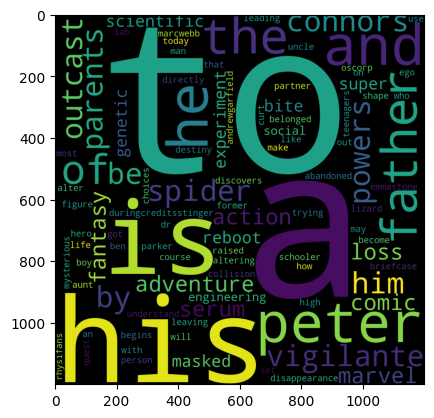

In [314]:
plt.imshow(wrd)

In [418]:
from sklearn.metrics.pairwise import cosine_similarity 
from sklearn.feature_extraction.text import CountVectorizer

In [419]:
cv = CountVectorizer(max_features=5000, stop_words='english')

In [420]:
vector=cv.fit_transform(final_df['tags'])

In [410]:
vector.shape

(4803, 5000)

In [421]:
cv.get_feature_names_out()[1:100]

array(['007', '10', '100', '11', '12', '13', '14', '15', '150', '15th',
       '16', '16th', '17', '17th', '18', '18th', '19', '1910', '1920',
       '1930', '1940', '1944', '1950', '1960', '1970', '1971', '1974',
       '1976', '1980', '1985', '1990', '1995', '1997', '1999', '19th',
       '20', '200', '2000', '2001', '2002', '2003', '2009', '20th',
       '21st', '23', '24', '25', '30', '300', '3d', '40', '50', '500',
       '51', '60', '70', '80', 'aaron', 'aaroneckhart', 'abandon', 'abbi',
       'abduct', 'abern', 'abigailbreslin', 'abil', 'abl', 'aboard',
       'aborigin', 'abov', 'abroad', 'absenc', 'abus', 'academ',
       'academi', 'accent', 'accept', 'access', 'accid', 'accident',
       'acclaim', 'accompani', 'accomplish', 'account', 'accus', 'ace',
       'achiev', 'acquaint', 'acquir', 'act', 'action', 'activ',
       'activist', 'actor', 'actress', 'actual', 'ad', 'adam',
       'adammckay', 'adamsandl'], dtype=object)

In [320]:
sim_scor1=cosine_similarity(vector,vector)
idx=final_df.index[final_df['title']=='Spectre'].to_list()[0]
sim_scores=list(enumerate(sim_scor1[idx]))  
sim_scores = sorted(sim_scores, key=lambda x: x[1],reverse=True)

In [321]:
idx=final_df.index[final_df['id']==126186].to_list()[0]

In [322]:
# problem in tags is so many word are repated form its meaning is same but  only write just like love
# loveing loved this tree word is same only test deferent so apply staming and convert in love 

In [422]:
import nltk
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [423]:
def stem(text):
   y = []
   for i in text.split():
       y.append(ps.stem(i))
   return " ".join(y)    

In [424]:
final_df['tags']=final_df['tags'].apply(stem)

C:\Users\rm948\AppData\Local\Temp\ipykernel_12864\3542233429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df['tags']=final_df['tags'].apply(stem)


In [428]:
vector=cv.fit_transform(final_df['tags']);

In [429]:
sim_score=cosine_similarity(vector,vector)

In [404]:
idx=final_df.index[final_df['title']=='Avatar'].to_list()[0]
idx

0

In [405]:
sim_score=sorted(list(enumerate(sim_score[idx])),key=lambda x: x[1],reverse=True)

In [351]:
sim_score=sim_score[1:15]

In [352]:
L=[]
for i in sim_score:
    L.append(i[0])

In [353]:
final_df.iloc[L]

,id,title,tags
2403,679,Aliens,horror action thriller sciencefict android ext...
4332,811,Silent Running,adventur drama sciencefict space marin sunligh...
373,2067,Mission to Mars,sciencefict mar spacecraft space travel alien ...
1531,698,Moonraker,action adventur thriller sciencefict venic mas...
3158,348,Alien,horror action thriller sciencefict android cou...
2015,957,Spaceballs,comedi sciencefict android lasergun swordplay ...
838,8077,Alien³,sciencefict action horror prison android space...
1914,11954,Lifeforce,fantasi horror sciencefict thriller space mari...
305,9016,Treasure Planet,adventur anim famili fantasi sciencefict cybor...
278,869,Planet of the Apes,thriller sciencefict action adventur gorilla s...


In [332]:
final_df.iloc[2].to_list()

[np.int64(206647),
 'Spectre',
 'action adventur crime spi base on novel secret agent sequel mi6 british secret servic unit kingdom a cryptic messag from bond s past send him on a trail to uncov a sinist organ while m battl polit forc to keep the secret servic aliv bond peel back the layer of deceit to reveal the terribl truth behind spectr danielcraig christophwaltz l aseydoux sammend']

In [333]:
final_df.iloc[1343].to_list()

[np.int64(36670),
 'Never Say Never Again',
 'adventur action thriller video game spi bahama british steal scuba dive scuba british secret servic jame bond return as the secret agent 007 one more time to battl the evil organ spectr bond must defeat largo who ha stolen two atom warhead for nuclear blackmail but bond ha an alli in largo s girlfriend the willowi domino who fall for bond and seek reveng thi is the last time for sean conneri as her majesti s secret agent 007 seanconneri kimbasing klausmariabrandau irvinkershn']

In [334]:
final_df.iloc[11].to_list()

[np.int64(10764),
 'Quantum of Solace',
 'adventur action thriller crime kill undercov secret agent british secret servic quantum of solac continu the adventur of jame bond after casino royal betray by vesper the woman he love 007 fight the urg to make hi latest mission person pursu hi determin to uncov the truth bond and m interrog mr white who reveal that the organ that blackmail vesper is far more complex and danger than anyon had imagin danielcraig olgakurylenko mathieuamalr marcforst']

In [341]:
final_df

,id,title,tags
0,19995,Avatar,action adventur fantasi sciencefict cultur cla...
1,285,Pirates of the Caribbean: At World's End,adventur fantasi action ocean drug abus exot i...
2,206647,Spectre,action adventur crime spi base on novel secret...
3,49026,The Dark Knight Rises,action crime drama thriller dc comic crime fig...
4,49529,John Carter,action adventur sciencefict base on novel mar ...
...,...,...,...
4798,9367,El Mariachi,action crime thriller unit state u2013mexico b...
4799,72766,Newlyweds,comedi romanc a newlyw coupl s honeymoon is up...
4800,231617,"Signed, Sealed, Delivered",comedi drama romanc tvmovi date love at first ...
4801,126186,Shanghai Calling,when ambiti new york attorney sam is sent to s...


In [386]:
def recommend(movie):
    movie_index = final_df[final_df['title'] == movie].index[0]
    distances = sim_score[movie_index]
    movies_list = sorted(list(enumerate(distances)),reverse=True,key=lambda x:x[1]) [1:10]
    
    for i in movies_list:
      print(final_df.iloc[i[0]].title)

In [392]:
movie_name=final_df['title'].sample().to_list()[0]
recommend(movie_name)

Some Guy Who Kills People
K-PAX
Regression
Total Recall
Freeze Frame
Jack Reacher
Case 39
Cure
Silver Linings Playbook


'Redbelt'

In [393]:
# final_df.to_csv('final_df_movie_recommend_system.csv', index=False)

In [394]:
final_df

,id,title,tags
0,19995,Avatar,action adventur fantasi sciencefict cultur cla...
1,285,Pirates of the Caribbean: At World's End,adventur fantasi action ocean drug abus exot i...
2,206647,Spectre,action adventur crime spi base on novel secret...
3,49026,The Dark Knight Rises,action crime drama thriller dc comic crime fig...
4,49529,John Carter,action adventur sciencefict base on novel mar ...
...,...,...,...
4798,9367,El Mariachi,action crime thriller unit state u2013mexico b...
4799,72766,Newlyweds,comedi romanc a newlyw coupl s honeymoon is up...
4800,231617,"Signed, Sealed, Delivered",comedi drama romanc tvmovi date love at first ...
4801,126186,Shanghai Calling,when ambiti new york attorney sam is sent to s...


array([[1.        , 0.07057847, 0.05177033, ..., 0.0743212 , 0.01655212,
        0.        ],
       [0.07057847, 1.        , 0.04445542, ..., 0.05743797, 0.        ,
        0.02175971],
       [0.05177033, 0.04445542, 1.        , ..., 0.03745029, 0.        ,
        0.        ],
       ...,
       [0.0743212 , 0.05743797, 0.03745029, ..., 1.        , 0.05388159,
        0.03666178],
       [0.01655212, 0.        , 0.        , ..., 0.05388159, 1.        ,
        0.08164966],
       [0.        , 0.02175971, 0.        , ..., 0.03666178, 0.08164966,
        1.        ]], shape=(4803, 4803))

In [416]:
import pickle 

In [430]:
# pickle.dump(sim_score,open('sim_score.pkl','wb'))

In [417]:
sim_score

array([[1.        , 0.07057847, 0.05177033, ..., 0.0743212 , 0.01655212,
        0.        ],
       [0.07057847, 1.        , 0.04445542, ..., 0.05743797, 0.        ,
        0.02175971],
       [0.05177033, 0.04445542, 1.        , ..., 0.03745029, 0.        ,
        0.        ],
       ...,
       [0.0743212 , 0.05743797, 0.03745029, ..., 1.        , 0.05388159,
        0.03666178],
       [0.01655212, 0.        , 0.        , ..., 0.05388159, 1.        ,
        0.08164966],
       [0.        , 0.02175971, 0.        , ..., 0.03666178, 0.08164966,
        1.        ]], shape=(4803, 4803))